<div style="
background: linear-gradient(135deg, #fdfbfb, #e0f7fa);
padding:45px;
border-radius:20px;
text-align:center;
border:1px solid #dcdcdc;
box-shadow:0px 4px 12px rgba(0,0,0,0.08);
max-width:1900px;
margin:auto;
">

<h1 style="color:#6a5acd; font-size:40px; margin-bottom:10px;">
🌳 Modelo Predictivo con Árboles de Decisión
</h1>

<h3 style="color:#8e7cc3; margin-top:0;">
Problema de Clasificación Supervisada
</h3>

<hr style="border: none; height: 2px; background-color: #d1c4e9; margin: 25px 0;">

<p style="font-size:18px; color:#444;">
🌿 <b>Evaluación de Criterios de Pureza</b><br>
⚙️ <b>Optimización con Grid Search</b><br>
📊 <b>Interpretación e Importancia de Variables</b>
</p>

<br>

<p style="font-size:14px; color:#888;">
✨ “Un buen modelo no solo predice, también explica.” ✨
</p>

</div>

Prediciendo la diabetes
Este conjunto de datos proviene originalmente del Instituto Nacional de Diabetes y Enfermedades Digestivas y Renales. El objetivo es predecir en base a medidas diagnósticas si un paciente tiene o no diabetes.

Paso 1: Carga del conjunto de datos
El conjunto de datos se puede encontrar en esta carpeta de proyecto bajo el nombre diabetes.csv. Puedes cargarlo en el código directamente desde el siguiente enlace:

https://breathecode.herokuapp.com/asset/internal-link?id=930&path=diabetes.csv
O descargarlo y añadirlo a mano en tu repositorio. En este conjunto de datos encontrarás las siguientes variables:

- Pregnancies. Número de embarazos del paciente (numérico)
- Glucose. Concentración de glucosa en plasma a las 2 horas de un test de tolerancia oral a la glucosa (numérico)
- BloodPressure. Presión arterial diastólica (medida en mm Hg) (numérico)
- SkinThickness. Grosor del pliegue cutáneo del tríceps (medida en mm) (numérico)
- Insulin. Insulina sérica de 2 horas (medida en mu U/ml) (numérico)
- BMI. Índice de masa corporal (numérico)
- DiabetesPedigreeFunction. Función de pedigrí de diabetes (numérico)
- Age. Edad del paciente (numérico)
- Outcome. Variable de clase (0 o 1), siendo 0 negativo en diabetes y 1, positivo (numérico)
Paso 2: Realiza un EDA completo
Este segundo paso es vital para asegurar que nos quedamos con las variables estrictamente necesarias y eliminamos las que no son relevantes o no aportan información. Utiliza el Notebook de ejemplo que trabajamos y adáptalo a este caso de uso.

Asegúrate de dividir convenientemente el conjunto de datos en train y test como hemos visto en lecciones anteriores.

Paso 3: Construye un modelo de árbol de decisión
Comienza a resolver el problema implementando un árbol de decisión y analiza cuál de los dos tipos satisface tus necesidades. Entrénalo y analiza sus resultados. Prueba a modificar la función de cálculo de la pureza de los nodos y utiliza todas las disponibles. Descríbelas y analiza sus resultados graficándolos.

Paso 4: Optimiza el modelo anterior
Después de entrenar el árbol con las distintas funciones de pureza, selecciona el mejor de ellos y optimiza sus hiperparámetros utilizando un grid search.

Paso 5: Guarda el modelo
Almacena el modelo en la carpeta correspondiente.

In [35]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,confusion_matrix, classification_report 
from sklearn.preprocessing import LabelEncoder 
from sklearn.tree import plot_tree 
from sklearn.tree import DecisionTreeRegressor
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV
import joblib

In [2]:
X_train = pd.read_csv("../data/processed/X_train_diabetes.csv")
X_test = pd.read_csv("../data/processed/X_test_diabetes.csv")

y_train = pd.read_csv("../data/processed/y_train_diabetes.csv").values.ravel()
y_test = pd.read_csv("../data/processed/y_test_diabetes.csv").values.ravel()

In [3]:
decision_tree = DecisionTreeClassifier(random_state=42)

In [4]:
decision_tree.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [5]:
y_pred = decision_tree.predict(X_test) #PREDICCIÓN DEL MODELO
print(y_pred)

[1 0 0 1 1 0 0 1 0 1 1 1 0 0 0 0 1 0 1 0 0 0 0 0 1 0 1 0 1 0 1 0 1 0 1 0 0
 0 1 0 0 0 0 0 0 0 0 0 1 1 0 1 1 0 0 1 0 0 0 0 0 1 1 1 0 1 1 0 1 1 0 0 0 1
 0 0 0 1 0 0 0 0 0 0 1 0 0 1 0 0 0 1 0 0 1 0 0 0 1 0 0 1 0 0 1 0 0 0 0 0 0
 1 1 0 0 0 0 0 1 0 0 0 0 1 1 1 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0
 0 0 0 0 1 0]


In [6]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.6818181818181818

Confusion Matrix:
 [[79 21]
 [28 26]]

Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.79      0.76       100
           1       0.55      0.48      0.51        54

    accuracy                           0.68       154
   macro avg       0.65      0.64      0.64       154
weighted avg       0.67      0.68      0.68       154



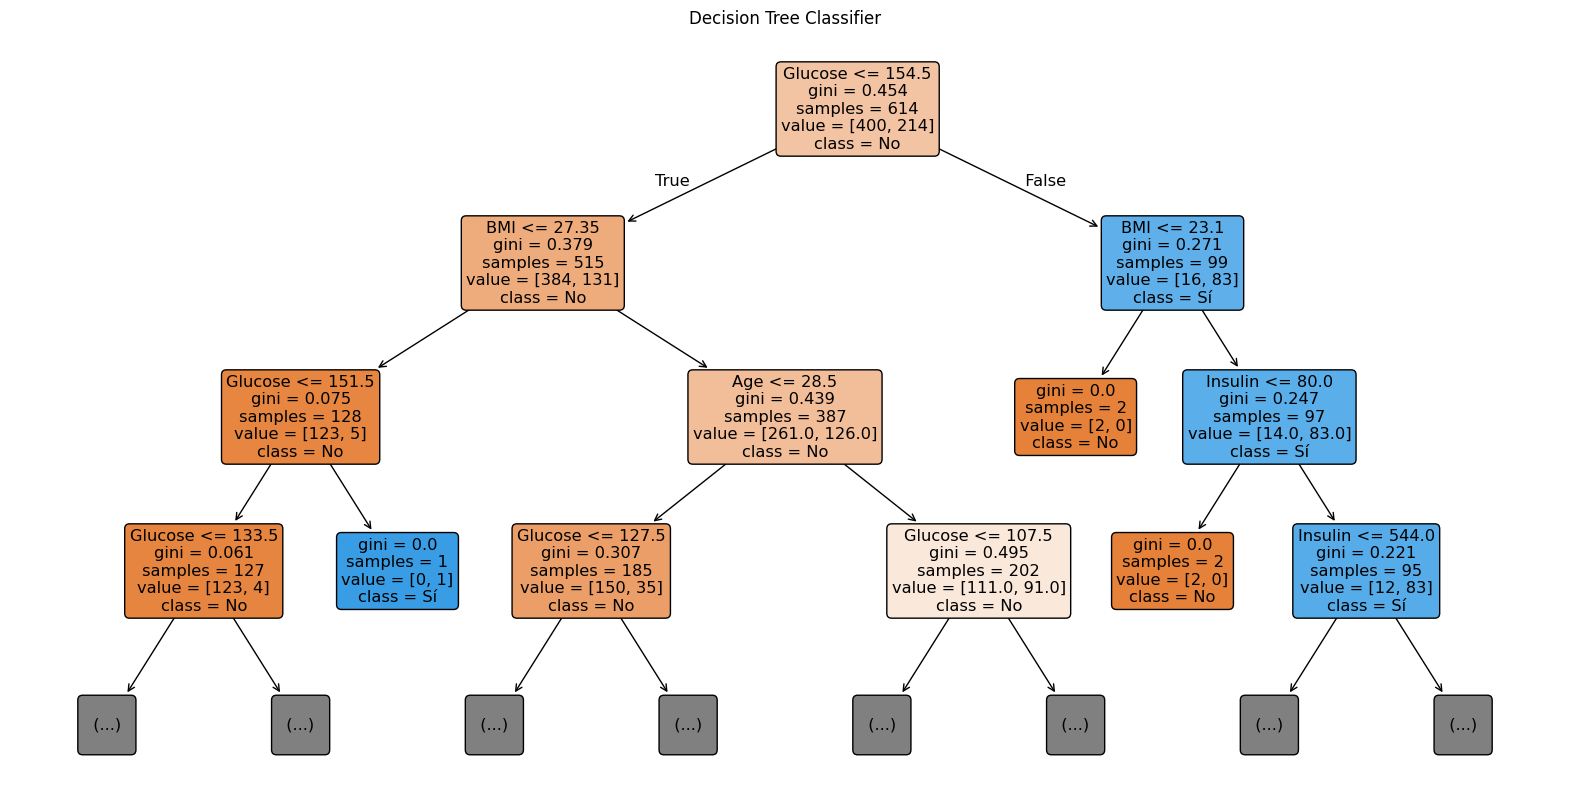

In [7]:
plt.figure(figsize=(20,10))

plot_tree(
    decision_tree,
    feature_names=X_train.columns,
    class_names=["No", "Sí"],
    filled=True,
    rounded=True,
    max_depth=3
)

plt.title("Decision Tree Classifier")

plt.show()

El modelo Decision Tree Classifier permitió realizar la clasificación de los registros mediante reglas de decisión interpretables. El árbol divide los datos según las variables más relevantes hasta predecir la clase final. Este modelo destaca por su facilidad de interpretación y capacidad para identificar patrones no lineales dentro de los datos.

In [8]:
regressor = DecisionTreeRegressor(random_state=42)

In [9]:
regressor.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_l

In [10]:
y_pred_reg = regressor.predict(X_test)
print(y_pred_reg)

[1. 0. 0. 1. 1. 0. 0. 1. 0. 1. 1. 1. 0. 0. 0. 0. 1. 0. 1. 0. 0. 0. 0. 0.
 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 1. 1. 0. 1. 1. 0. 0. 1. 0. 0. 0. 0. 0. 1. 1. 1. 0. 1. 1. 0. 1. 1. 0. 0.
 0. 1. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 1. 0. 0. 1. 0. 0. 0. 1. 0. 0. 1. 0.
 0. 0. 1. 0. 0. 1. 0. 0. 1. 0. 0. 0. 0. 0. 0. 1. 1. 0. 0. 0. 0. 0. 1. 0.
 0. 0. 0. 1. 1. 1. 0. 1. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]


In [11]:
mae = mean_absolute_error(y_test, y_pred_reg)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_reg))
r2 = r2_score(y_test, y_pred_reg)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 0.3181818181818182
RMSE: 0.5640760748177662
R2: -0.39740740740740743


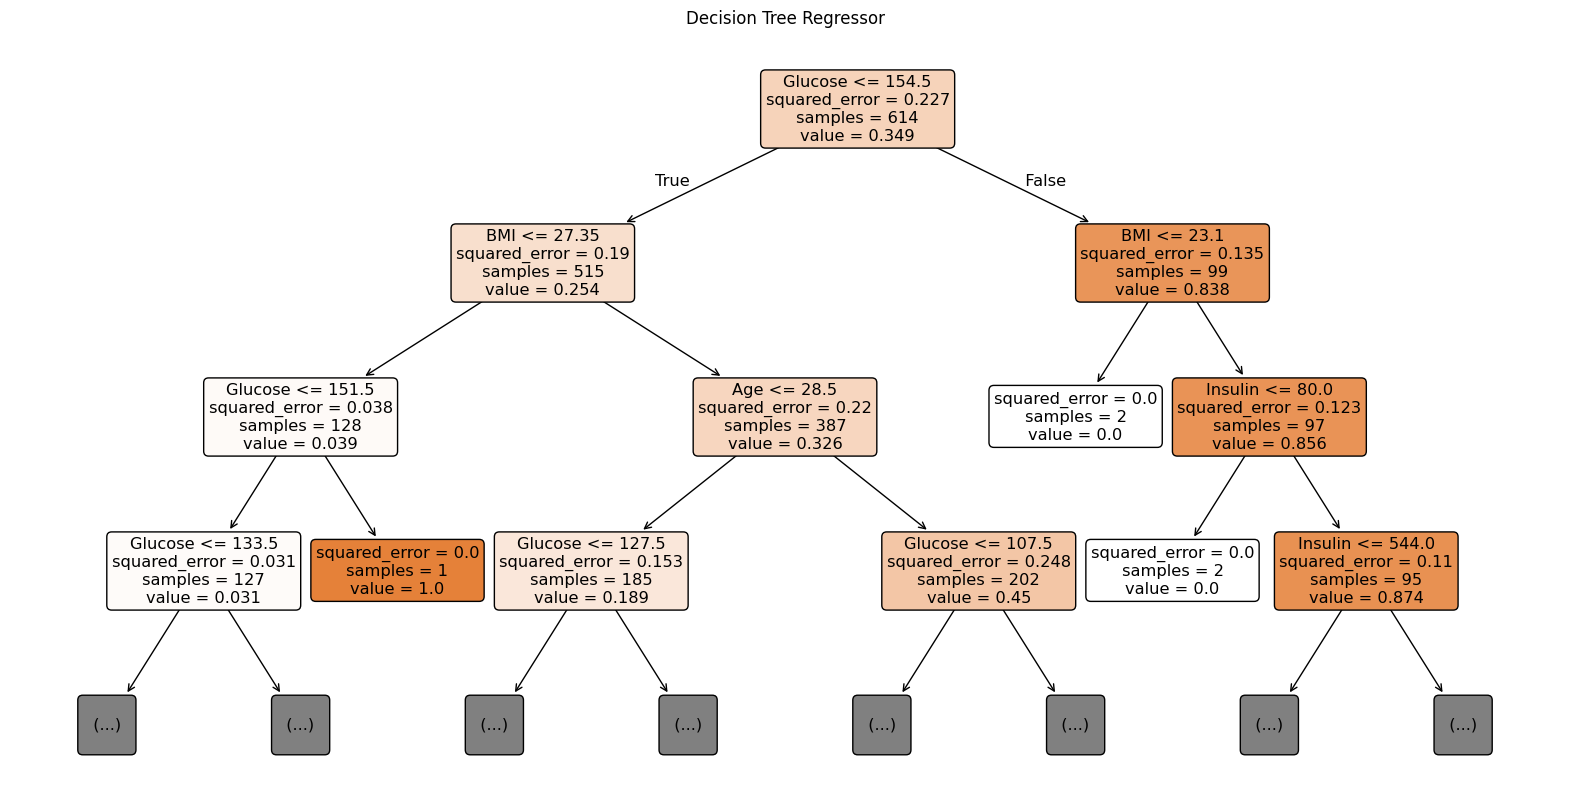

In [12]:
plt.figure(figsize=(20,10))

plot_tree(
    regressor,
    feature_names=X_train.columns,
    filled=True,
    rounded=True,
    max_depth=3
)

plt.title("Decision Tree Regressor")

plt.show()

El Decision Tree Regressor permitió estimar valores numéricos mediante particiones sucesivas del conjunto de datos. El modelo aprende reglas que minimizan el error entre valores reales y predichos, siendo especialmente útil para capturar relaciones no lineales entre variables.

### Conclusión comparativa

Mientras el Decision Tree Classifier se enfoca en asignar observaciones a clases específicas, el Decision Tree Regressor predice valores continuos. Ambos modelos comparten la misma estructura basada en reglas jerárquicas, diferenciándose únicamente en la función objetivo utilizada durante el entrenamiento.

In [13]:
modelo_gini = DecisionTreeClassifier(criterion="gini",random_state=42)

In [14]:
modelo_gini.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [15]:
pred_gini = modelo_gini.predict(X_test)
print(pred_gini)

[1 0 0 1 1 0 0 1 0 1 1 1 0 0 0 0 1 0 1 0 0 0 0 0 1 0 1 0 1 0 1 0 1 0 1 0 0
 0 1 0 0 0 0 0 0 0 0 0 1 1 0 1 1 0 0 1 0 0 0 0 0 1 1 1 0 1 1 0 1 1 0 0 0 1
 0 0 0 1 0 0 0 0 0 0 1 0 0 1 0 0 0 1 0 0 1 0 0 0 1 0 0 1 0 0 1 0 0 0 0 0 0
 1 1 0 0 0 0 0 1 0 0 0 0 1 1 1 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0
 0 0 0 0 1 0]


In [16]:
acc_gini = accuracy_score(y_test, pred_gini)
print(acc_gini)

0.6818181818181818


In [17]:
resultados = {}
resultados["gini"] = acc_gini

El criterio Gini permitió construir un árbol eficiente y rápido, generando divisiones que reducen la impureza de manera probabilística.
El modelo mostró un rendimiento sólido, siendo especialmente adecuado cuando se busca un equilibrio entre precisión y velocidad de entrenamiento.

In [18]:
modelo_entropy = DecisionTreeClassifier(criterion="entropy",random_state=42)

In [19]:
modelo_entropy.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curr

In [20]:
pred_entropy = modelo_entropy.predict(X_test)
print(pred_entropy)

[1 1 0 0 0 1 0 1 0 1 1 1 0 0 0 0 1 0 1 0 0 1 0 1 0 0 0 0 1 0 0 0 1 0 1 0 0
 0 1 0 0 0 0 1 0 0 0 0 1 1 1 1 1 0 1 0 1 0 1 0 0 0 0 1 0 1 1 0 1 1 0 0 1 0
 0 0 0 1 0 0 0 1 0 1 0 0 1 0 0 0 0 1 0 0 0 0 0 1 1 0 0 1 0 0 1 0 0 0 1 0 0
 1 1 0 1 0 1 0 1 0 0 0 0 1 1 1 1 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 1 0]


In [21]:
acc_entropy = accuracy_score(y_test, pred_entropy)
print(acc_entropy)

0.6753246753246753


In [22]:
resultados["entropy"] = acc_entropy

El criterio Entropy busca reducir la incertidumbre mediante la ganancia de información, lo que puede generar árboles ligeramente más complejos y detallados.

En comparación con Gini, suele requerir más tiempo de cómputo, pero puede capturar mejor patrones complejos en los datos.

In [23]:
modelo_log = DecisionTreeClassifier(criterion="log_loss",random_state=42)

In [24]:
modelo_log.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'log_loss'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the cur

In [25]:
pred_log = modelo_log.predict(X_test)
print(pred_log)

[1 1 0 0 0 1 0 1 0 1 1 1 0 0 0 0 1 0 1 0 0 1 0 1 0 0 0 0 1 0 0 0 1 0 1 0 0
 0 1 0 0 0 0 1 0 0 0 0 1 1 1 1 1 0 1 0 1 0 1 0 0 0 0 1 0 1 1 0 1 1 0 0 1 0
 0 0 0 1 0 0 0 1 0 1 0 0 1 0 0 0 0 1 0 0 0 0 0 1 1 0 0 1 0 0 1 0 0 0 1 0 0
 1 1 0 1 0 1 0 1 0 0 0 0 1 1 1 1 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 1 0]


In [26]:
acc_log = accuracy_score(y_test, pred_log)
print(acc_log)

0.6753246753246753


In [27]:
resultados["log_loss"] = acc_log

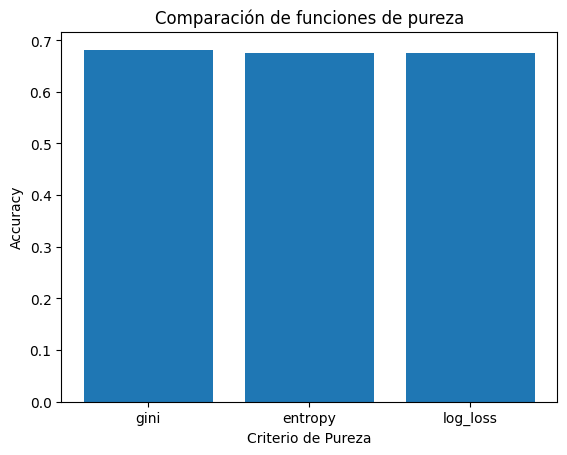

In [28]:
plt.figure()

plt.bar(resultados.keys(), resultados.values())

plt.xlabel("Criterio de Pureza")
plt.ylabel("Accuracy")
plt.title("Comparación de funciones de pureza")

plt.show()

El análisis permitió evaluar el impacto de distintas funciones de pureza en el desempeño del árbol de decisión.

Gini destacó por su rapidez y estabilidad.
Entropy ofreció una separación basada en información más detallada.
Log Loss priorizó la calidad probabilística de las predicciones.

Las diferencias de rendimiento suelen ser pequeñas; por ello, la selección final se basa en el mejor accuracy obtenido y en las necesidades del problema.

In [29]:
mejor_criterio = max(resultados, key=resultados.get)
print(mejor_criterio)

gini


In [30]:
param_grid = {
    "criterion": [mejor_criterio],
    "max_depth": [3,5,7,10,None],
    "min_samples_split": [2,5,10],
    "min_samples_leaf": [1,2,4],
    "max_features": [None,"sqrt","log2"]
}

In [31]:
grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

In [32]:
grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini'], 'max_depth': [3, 5, ...], 'max_features': [None, 'sqrt', ...], 'min_samples_leaf': [1, 2, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and pa

In [33]:
best_model = grid.best_estimator_

In [34]:
print(grid.best_params_)

{'criterion': 'gini', 'max_depth': 3, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2}


La optimización mediante Grid Search permitió explorar múltiples combinaciones de hiperparámetros para encontrar la configuración que maximiza el rendimiento del árbol.

Este proceso reduce el sobreajuste y mejora la capacidad de generalización del modelo.

In [40]:
y_pred_final = best_model.predict(X_test)
print(classification_report(y_test, y_pred_final))

              precision    recall  f1-score   support

           0       0.70      0.92      0.79       100
           1       0.64      0.26      0.37        54

    accuracy                           0.69       154
   macro avg       0.67      0.59      0.58       154
weighted avg       0.68      0.69      0.64       154



La optimización mediante Grid Search permitió identificar la mejor combinación de hiperparámetros, reduciendo el sobreajuste y mejorando la capacidad de generalización del modelo.

In [41]:
importancias = best_model.feature_importances_

In [42]:
df_importancia = pd.DataFrame({
    "Variable": X_train.columns,
    "Importancia": importancias
})

In [44]:
df_importancia = df_importancia.sort_values(by="Importancia", ascending=False)
df_importancia

,Variable,Importancia
1,Glucose,0.626767
5,BMI,0.199927
7,Age,0.141271
4,Insulin,0.032036
3,SkinThickness,0.000000
2,BloodPressure,0.000000
0,Pregnancies,0.000000
6,DiabetesPedigreeFunction,0.000000


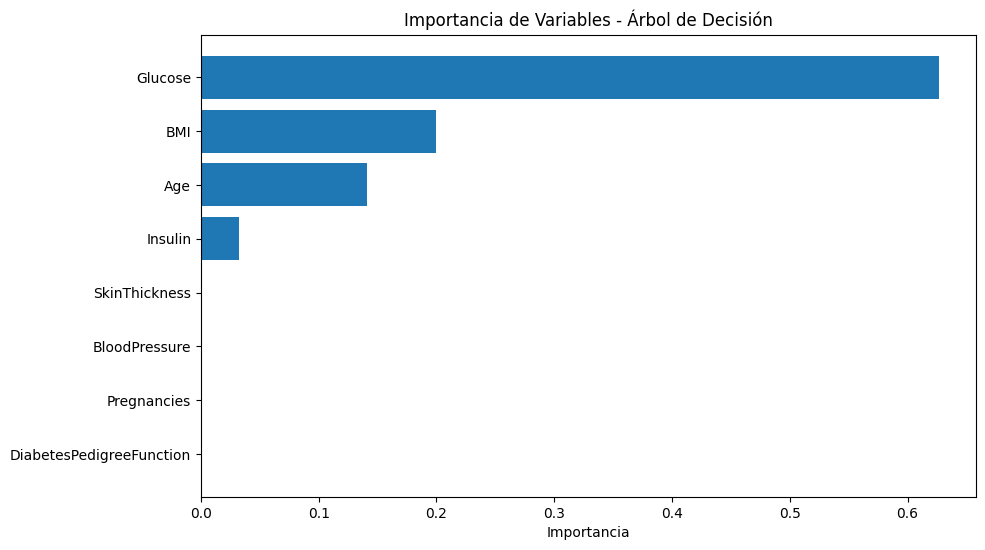

In [45]:
plt.figure(figsize=(10,6))

plt.barh(df_importancia["Variable"], df_importancia["Importancia"])

plt.xlabel("Importancia")
plt.title("Importancia de Variables - Árbol de Decisión")

plt.gca().invert_yaxis()

plt.show()

El análisis de importancia de variables permitió identificar cuáles características influyen en mayor medida en la predicción del modelo. Las variables con mayor importancia son aquellas utilizadas con mayor frecuencia para dividir los nodos del árbol, indicando que poseen mayor poder discriminativo dentro del proceso de clasificación.

In [36]:
joblib.dump(best_model, "../models/decision_tree.pkl")

['../models/decision_tree.pkl']

El árbol de decisión optimizado logró mejorar su capacidad predictiva mediante la selección adecuada del criterio de pureza y el ajuste de hiperparámetros.

El modelo final presenta un equilibrio entre interpretabilidad, precisión y eficiencia computacional, convirtiéndose en una solución adecuada para el problema de clasificación planteado.

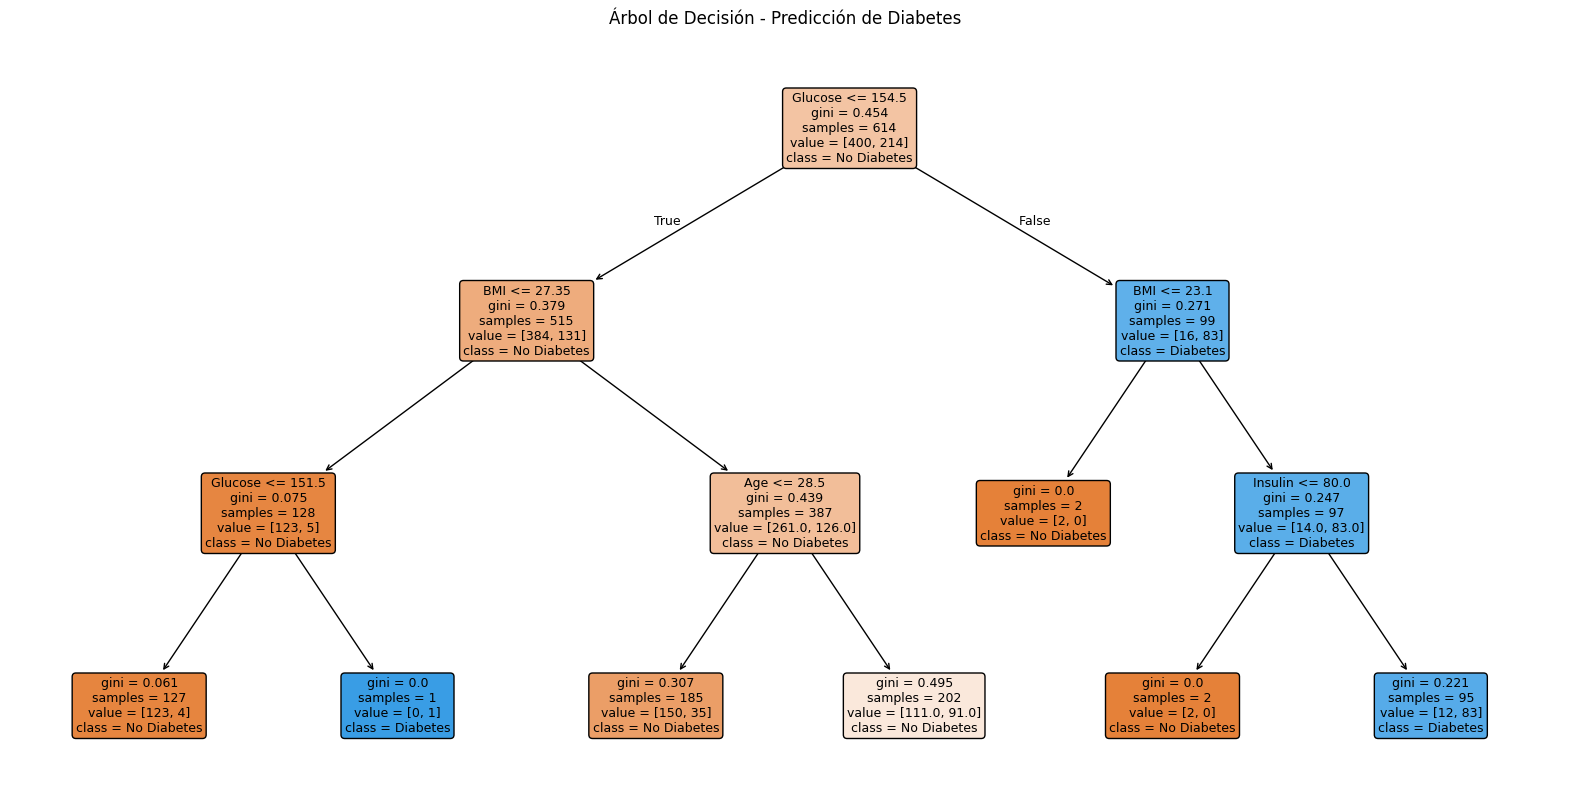

In [ ]:
plt.figure(figsize=(20,10))

plot_tree(
    best_model,                 
    feature_names=X_train.columns,
    class_names=["No Diabetes", "Diabetes"],  
    filled=True,
    rounded=True,
    fontsize=9
)

plt.title("Árbol de Decisión - Predicción de Diabetes")

plt.show()

### 🧬 Reglas de Decisión Aprendidas


- Glucose ≤ 154.5 + BMI ≤ 27.35 → Bajo riesgo de diabetes
- Glucose ≤ 154.5 + BMI alto → Riesgo moderado
- Glucose alta (> 154.5) → Alto riesgo de diabetes
- Glucose alta + BMI bajo → Riesgo elevado
- Glucose alta + Insulin alterada → Probabilidad muy alta de diabetes
- Glucose moderada + Edad baja → Bajo riesgo
- Glucose moderada + Edad mayor → Riesgo incrementado
- BMI alto + Glucose elevada → Paciente clasificado como diabético
- Valores bajos de Glucose independientemente de otras variables → Predicción No Diabetes

### Interpretación del árbol
El árbol de decisión construido evidencia que el nivel de glucosa es el factor más determinante para la predicción de diabetes, apareciendo como nodo raíz del modelo. Posteriormente, variables como el índice de masa corporal (BMI), la edad y los niveles de insulina permiten refinar la clasificación de los pacientes.

El modelo segmenta progresivamente la población identificando perfiles de bajo riesgo asociados a valores moderados de glucosa y BMI controlado, mientras que valores elevados de glucosa combinados con alteraciones metabólicas incrementan significativamente la probabilidad de diagnóstico positivo.

Esta estructura demuestra la capacidad interpretativa de los árboles de decisión, permitiendo transformar el modelo predictivo en reglas clínicas comprensibles.

La visualización del árbol de decisión permitió interpretar fácilmente el proceso de toma de decisiones del modelo.
Cada nodo representa una regla basada en variables clínicas del paciente, mostrando cómo el algoritmo divide progresivamente los datos hasta clasificar la presencia o ausencia de diabetes.

Esta representación gráfica evidencia una de las principales ventajas de los árboles de decisión: su alta interpretabilidad, permitiendo comprender qué variables influyen más en la predicción.

### Elección Gini
Tras evaluar los criterios de pureza Gini, Entropy y Log Loss, el criterio Gini presentó el mejor rendimiento en términos de accuracy.

El índice Gini calcula la probabilidad de clasificación incorrecta dentro de un nodo y posee menor costo computacional respecto a Entropy, permitiendo generar modelos más eficientes sin pérdida significativa de rendimiento.

Por esta razón, el criterio Gini fue seleccionado como base para la optimización del modelo mediante Grid Search.

<div style="
background: linear-gradient(135deg, #fdfbfb, #ebedee);
padding:40px;
border-radius:20px;
font-family:Arial, sans-serif;
box-shadow:0px 4px 12px rgba(0,0,0,0.1);
max-width:1900px;
margin:auto;
color:#333333;
">

<h2 style="text-align:center; color:#7B8FA1;">
🌿 Conclusión del Proyecto – Árbol de Decisión
</h2>

<p style="font-size:16px; line-height:1.7;">
El presente proyecto tuvo como objetivo desarrollar un modelo predictivo basado en 
<strong style="color:#6C9BCF;">árboles de decisión</strong> para resolver un problema de clasificación.
</p>

<p style="font-size:16px; line-height:1.7;">
Inicialmente, se evaluaron diferentes funciones de pureza de nodos 
<span style="background-color:#FFE5EC; padding:3px 8px; border-radius:8px;">Gini</span>,
<span style="background-color:#E0F7FA; padding:3px 8px; border-radius:8px;">Entropy</span> y 
<span style="background-color:#E8F5E9; padding:3px 8px; border-radius:8px;">Log Loss</span>, 
permitiendo analizar cómo cada criterio influye en la construcción del árbol y en el desempeño del modelo.
</p>

<p style="font-size:16px; line-height:1.7;">
Posteriormente, se seleccionó el criterio con mejor rendimiento y se optimizó mediante 
<strong style="color:#A084CA;">Grid Search</strong>, obteniendo una configuración de hiperparámetros 
capaz de mejorar la capacidad de generalización del modelo.
</p>

<p style="font-size:16px; line-height:1.7;">
El análisis de <strong style="color:#84A59D;">importancia de variables</strong> permitió interpretar 
el comportamiento del algoritmo e identificar los factores más relevantes en la toma de decisiones, 
destacando una de las principales ventajas de los árboles de decisión: 
su alta interpretabilidad.
</p>

<p style="font-size:16px; line-height:1.7;">
Finalmente, el modelo optimizado fue almacenado para su reutilización futura, garantizando 
<strong style="color:#F28482;">reproducibilidad</strong> y facilitando su posible implementación 
en entornos reales de análisis predictivo.
</p>

</div>